## 0. Setup & Imports
All libraries below ship with Google Colab. `open3d` is optional (commented out) — the pipeline does not need it.

In [ ]:
# !pip install open3d -q   # optional, NOT required
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa
from scipy.spatial import cKDTree
from sklearn.cluster import DBSCAN

np.set_printoptions(precision=3, suppress=True)
RNG = np.random.default_rng(42)   # reproducible
print("Setup done. numpy", np.__version__)

Setup done. numpy 2.0.2


## 1. Staircase Geometric Parameters
Following the recommended specification:

| Parameter | Symbol | Value | Assignment range |
|---|---|---|---|
| Staircase width (x-axis) | `WIDTH` | 2.5 m | 2.0–3.0 m |
| Tread depth (y-axis) | `DEPTH` | 0.30 m | 0.25–0.35 m |
| Step height (z-axis) | `HEIGHT` | 0.18 m | 0.15–0.20 m |
| Number of steps | `N_STEPS` | 4 | 4 |

Total run length = `N_STEPS × DEPTH = 1.2 m`. Noise and point counts are set so the total is **±15,000–25,000 points**.

In [ ]:
# ---------- Geometric parameters ----------
WIDTH    = 2.5    # staircase width (x-axis), meters
DEPTH    = 0.30   # tread depth     (y-axis), meters
HEIGHT   = 0.18   # rise / height   (z-axis), meters
N_STEPS  = 4

# ---------- Noise & sampling parameters ----------
SIGMA_Z      = 0.02    # std of vertical noise on tread (N(0, 0.02^2))
SIGMA_Y      = 0.02    # std of noise on riser (y direction)
LIDAR_NOISE  = 0.005   # isotropic LiDAR noise on all axes
N_TREAD      = 2600    # points per tread
N_RISER      = 1600    # points per riser
OUTLIER_FRAC = 0.04    # 4% outliers

# Ground-truth labels: 0 = other/outlier, 1 = tread (walkable), 2 = riser
LABELS = {0: "Other/Noise", 1: "Tread (walkable)", 2: "Riser (vertical)"}

## 2. Mathematical Equations for Data Generation

**a. Horizontal Surface — *Tread* (walkable)** for step $i$, $i=0,\dots,3$:

$$
\begin{cases}
x \sim \mathrm{Uniform}(0,\ \text{width}) \\[2pt]
y \sim \mathrm{Uniform}\big(i\cdot\text{depth},\ (i+1)\cdot\text{depth}\big) \\[2pt]
z = i\cdot\text{height} + \epsilon_z,\quad \epsilon_z \sim \mathcal{N}(0,\ 0.02^2)
\end{cases}
$$

**b. Vertical Surface — *Riser*** for step $i$, $i=1,\dots,3$:

$$
\begin{cases}
x \sim \mathrm{Uniform}(0,\ \text{width}) \\[2pt]
y = i\cdot\text{depth} + \epsilon_y,\quad \epsilon_y \sim \mathcal{N}(0,\ 0.02^2) \\[2pt]
z \sim \mathrm{Uniform}\big((i-1)\cdot\text{height},\ i\cdot\text{height}\big)
\end{cases}
$$

> **Note:** risers are generated for $i=1,2,3$ only. For $i=0$ the riser equation gives $z\in[-\text{height},0]$ (below the floor), so it is skipped — a geometric choice consistent with an ascending staircase.

**c. LiDAR Noise & Outliers.** Each point gets isotropic noise $\mathcal{N}(0, 0.005^2)$ to mimic sensor noise, then ±4% random points (*outliers*) are added across the whole *bounding box*.

In [ ]:
def generate_staircase():
    pts, lbl = [], []

    # (a) TREAD — horizontal surface, i = 0..3
    for i in range(N_STEPS):
        x = RNG.uniform(0, WIDTH, N_TREAD)
        y = RNG.uniform(i*DEPTH, (i+1)*DEPTH, N_TREAD)
        z = i*HEIGHT + RNG.normal(0, SIGMA_Z, N_TREAD)
        pts.append(np.c_[x, y, z]); lbl.append(np.full(N_TREAD, 1))

    # (b) RISER — vertical surface, i = 1..3
    for i in range(1, N_STEPS):
        x = RNG.uniform(0, WIDTH, N_RISER)
        y = i*DEPTH + RNG.normal(0, SIGMA_Y, N_RISER)
        z = RNG.uniform((i-1)*HEIGHT, i*HEIGHT, N_RISER)
        pts.append(np.c_[x, y, z]); lbl.append(np.full(N_RISER, 2))

    P = np.vstack(pts); y_true = np.concatenate(lbl)

    # (c1) isotropic LiDAR noise
    P += RNG.normal(0, LIDAR_NOISE, P.shape)

    # (c2) random outliers across the bounding box
    n_out = int(len(P) * OUTLIER_FRAC)
    out = np.c_[
        RNG.uniform(0, WIDTH, n_out),
        RNG.uniform(0, N_STEPS*DEPTH, n_out),
        RNG.uniform(-0.05, N_STEPS*HEIGHT + 0.10, n_out),
    ]
    P = np.vstack([P, out]); y_true = np.concatenate([y_true, np.zeros(n_out)])

    # shuffle to avoid ordering bias
    perm = RNG.permutation(len(P))
    return P[perm], y_true[perm].astype(int)


P, y_true = generate_staircase()
print(f"Total points : {len(P):,}")
for k, v in LABELS.items():
    print(f"  {v:24s}: {(y_true==k).sum():,} points")

Total points : 15,808
  Other/Noise             : 608 points
  Tread (walkable)        : 10,400 points
  Riser (vertical)        : 4,800 points


## 3. Raw Point Cloud Visualization (before segmentation)
Colored by height (z) — the four steps are visible. A subset of points is shown for fast rendering.

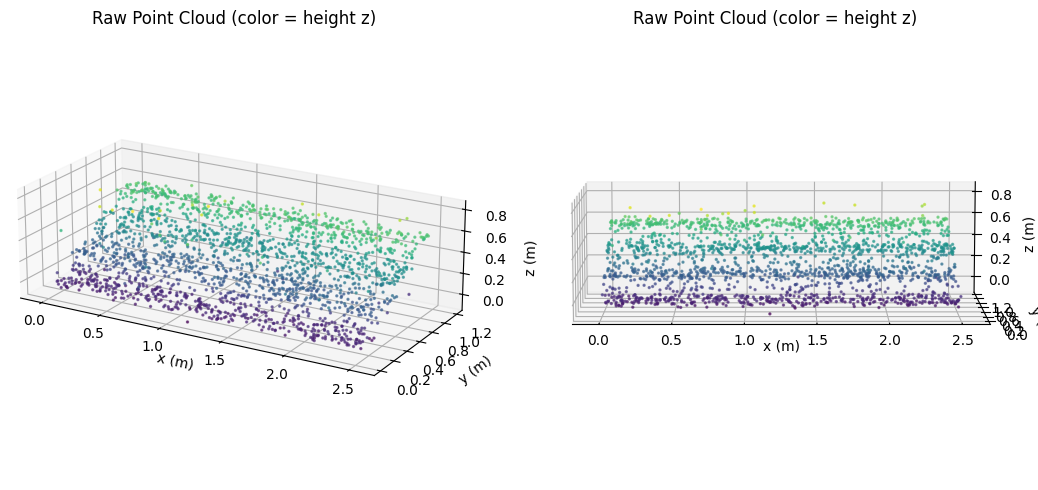

In [ ]:
def plot3d(P, colors, title, sub=8, cmap=None, legend=None):
    fig = plt.figure(figsize=(11,5))
    for k,(elev,azim) in enumerate([(20,-60),(8,-90)]):
        ax = fig.add_subplot(1,2,k+1, projection='3d')
        s = ax.scatter(P[::sub,0], P[::sub,1], P[::sub,2],
                       c=colors[::sub], s=2, cmap=cmap, alpha=0.6)
        ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)'); ax.set_zlabel('z (m)')
        ax.set_title(title); ax.view_init(elev=elev, azim=azim)
        try: ax.set_box_aspect((WIDTH, N_STEPS*DEPTH, N_STEPS*HEIGHT))
        except Exception: pass
    if legend: fig.legend(handles=legend, loc='lower center', ncol=3)
    plt.tight_layout(); plt.show()

plot3d(P, P[:,2], "Raw Point Cloud (color = height z)", cmap='viridis')

## 4. Surface Normal Estimation (basis for several methods)
For each point we find its $k$ nearest neighbors (KD-Tree), then compute the local covariance matrix. The **normal vector** is the *eigenvector* with the smallest *eigenvalue* (direction of minimum variance).

$$
\mathbf{C}_p = \frac{1}{k}\sum_{j=1}^{k}(\mathbf{q}_j-\bar{\mathbf q})(\mathbf{q}_j-\bar{\mathbf q})^\top,
\qquad
\mathbf{n}_p = \arg\min_{\|\mathbf v\|=1}\ \mathbf v^\top \mathbf{C}_p \mathbf v
$$

The component $|n_z|$ indicates orientation: $|n_z|\!\to\!1$ ⇒ **horizontal** surface (tread); $|n_z|\!\to\!0$ ⇒ **vertical** surface (riser).

In [ ]:
def estimate_normals(points, k=30):
    tree = cKDTree(points)
    _, idx = tree.query(points, k=k)          # nearest neighbors (vectorized)
    nbrs = points[idx]
    nbrs = nbrs - nbrs.mean(axis=1, keepdims=True)
    cov = np.einsum('nki,nkj->nij', nbrs, nbrs) / k   # per-point covariance
    _, vecs = np.linalg.eigh(cov)             # eigh -> ascending
    return vecs[:, :, 0]                      # eigenvector of smallest eigenvalue = normal

normals = estimate_normals(P, k=30)
nz = np.abs(normals[:, 2])                    # |n_z| as orientation feature
print("mean |n_z| tread :", nz[y_true==1].mean().round(3))
print("mean |n_z| riser :", nz[y_true==2].mean().round(3))

mean |n_z| tread : 0.896
mean |n_z| riser : 0.346


## 5. Method 1 — RANSAC Plane Fitting (horizontal planes)
As required: detect **horizontal planes** with **normal ≈ Z-axis**. The plane model $\mathbf n^\top \mathbf x + d = 0$ is fit from 3 random points; **a candidate is accepted only if the normal is nearly aligned with the target axis** ($|n_z|>0.9$ for treads, $|n_y|>0.9$ for risers). Dominant planes are extracted iteratively (remove-inliers).

Because a horizontal slab of thickness `thresh` can also capture *riser* points at the same height, plane membership is **combined with local normal consistency** ($|n_z|>0.8$). This highlights a key point: pure geometric RANSAC needs to be supported by normal analysis.

In [ ]:
def ransac_plane(pts, idxs, axis, thr_normal=0.9, thresh=0.02, iters=800):
    '''Single-plane RANSAC; only accepts planes whose normal aligns with `axis`.'''
    sub = pts[idxs]; n = len(sub); best = 0; best_in = None; best_n = None
    for _ in range(iters):
        s = RNG.choice(n, 3, replace=False)
        p1, p2, p3 = sub[s]
        nm = np.cross(p2-p1, p3-p1); ln = np.linalg.norm(nm)
        if ln < 1e-6: continue
        nm /= ln
        if abs(nm[axis]) < thr_normal:           # lock plane orientation
            continue
        d = -nm.dot(p1)
        inl = np.abs(sub @ nm + d) < thresh
        c = inl.sum()
        if c > best: best, best_in, best_n = c, inl, nm
    if best_in is None: return None, np.array([], int)
    return best_n, idxs[best_in]

def segment_ransac(P, nz, thresh=0.02, min_inl=250):
    pred = np.zeros(len(P), int); rem = np.arange(len(P))
    # Pass-1: horizontal planes (tread), normal ~ Z, + local vertical-normal check
    for _ in range(N_STEPS + 2):
        if len(rem) < 50: break
        nm, inl = ransac_plane(P, rem, axis=2, thr_normal=0.9, thresh=thresh)
        if nm is None or len(inl) < min_inl: break
        pred[inl[nz[inl] > 0.80]] = 1            # plane ∩ vertical normal
        rem = np.setdiff1d(rem, inl)
    # Riser (for visualization): remaining points with horizontal normal
    pred[(pred == 0) & (nz < 0.40)] = 2
    return pred

pred_ransac = segment_ransac(P, nz)
print("RANSAC -> tread:", (pred_ransac==1).sum(), " riser:", (pred_ransac==2).sum())

RANSAC -> tread: 8726  riser: 3597


## 6. Method 2 — PCA + Normal Vector Analysis
Classify each point directly from the normal orientation obtained via local PCA (Section 4):

$$
\text{label}(p)=
\begin{cases}
\textbf{tread} & |n_z| > \tau_h \;(=0.85)\\
\textbf{riser} & |n_z| < \tau_v \;(=0.35)\\
\textbf{other} & \text{otherwise (edge/transition)}
\end{cases}
$$

Simple, fast, and usually the most accurate on staircase geometry where the planes are well defined.

In [ ]:
def segment_pca_normal(nz, tau_h=0.85, tau_v=0.35):
    pred = np.zeros(len(nz), int)
    pred[nz > tau_h] = 1     # tread
    pred[nz < tau_v] = 2     # riser
    return pred

pred_pca = segment_pca_normal(nz)
print("PCA+Normal -> tread:", (pred_pca==1).sum(), " riser:", (pred_pca==2).sum())

PCA+Normal -> tread: 8991  riser: 3277


## 7. Method 3 — DBSCAN Clustering + Slope Analysis
In a dense staircase, *tread* and *riser* touch each other, so pure spatial DBSCAN tends to merge them. The strategy used: **DBSCAN as an outlier rejector** (points labeled `-1`), then valid points are **classified by local normal slope** ($|n_z|$). This is a valid combination of *density clustering* + *slope analysis*.

In [ ]:
def segment_dbscan(P, nz, eps=0.04, min_samples=10, tau_h=0.85, tau_v=0.35):
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit(P).labels_
    valid = labels != -1                       # reject noise/outliers
    pred = np.zeros(len(P), int)
    pred[valid & (nz > tau_h)] = 1             # tread
    pred[valid & (nz < tau_v)] = 2             # riser
    return pred, labels

pred_dbscan, db_labels = segment_dbscan(P, nz)
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
print(f"DBSCAN -> {n_clusters} clusters, noise {(db_labels==-1).mean()*100:.1f}%"
      f" | tread: {(pred_dbscan==1).sum()}  riser: {(pred_dbscan==2).sum()}")

DBSCAN -> 2 clusters, noise 5.2% | tread: 8668  riser: 3045


## 8. Method 4 (Bonus) — Height Histogram Analysis
*Treads* concentrate at discrete heights $z \approx 0,\,h,\,2h,\,3h$. A histogram of $z$ shows a **peak** at each level. We take the `N_STEPS` tallest peaks separated by more than 8 cm; points within $\pm z_{tol}$ of a peak **and** with a vertical normal ($|n_z|>0.75$) are marked as *tread*.

Detected height peaks (m): [0.009 0.181 0.352 0.542]  (ideal: [0.0, 0.18, 0.36, 0.54] )


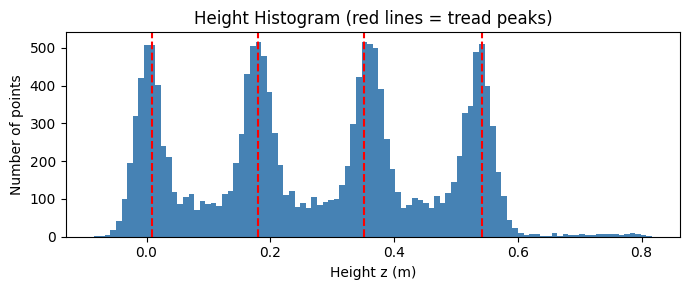

In [ ]:
def segment_height_hist(P, nz, z_tol=0.04, n_levels=N_STEPS):
    z = P[:, 2]
    hist, edges = np.histogram(z, bins=100)
    centers = (edges[:-1] + edges[1:]) / 2
    # find local maxima, then pick n_levels tallest peaks separated by >8cm
    cand = [(hist[i], centers[i]) for i in range(1, len(hist)-1)
            if hist[i] >= hist[i-1] and hist[i] >= hist[i+1]]
    cand.sort(reverse=True)
    peaks = []
    for h, c in cand:
        if all(abs(c - pc) > 0.08 for pc in peaks):
            peaks.append(c)
        if len(peaks) >= n_levels: break
    pred = np.zeros(len(P), int)
    for pk in sorted(peaks):
        pred[(np.abs(z - pk) < z_tol) & (nz > 0.75)] = 1
    pred[(pred == 0) & (nz < 0.40)] = 2
    return pred, sorted(peaks)

pred_hist, peaks = segment_height_hist(P, nz)
print("Detected height peaks (m):", np.round(peaks, 3),
      " (ideal:", [round(i*HEIGHT,2) for i in range(N_STEPS)], ")")

plt.figure(figsize=(7,3))
plt.hist(P[:,2], bins=100, color='steelblue')
for pk in peaks: plt.axvline(pk, color='red', ls='--')
plt.xlabel('Height z (m)'); plt.ylabel('Number of points'); plt.title('Height Histogram (red lines = tread peaks)')
plt.tight_layout(); plt.show()

## 9. Evaluation — Metrics for the *Walkable* Class
Positive class = **tread** (label 1). With TP/FP/FN/TN:

$$
\text{Acc}=\frac{TP+TN}{N},\;
\text{Prec}=\frac{TP}{TP+FP},\;
\text{Rec}=\frac{TP}{TP+FN},\;
F1=\frac{2\,PR}{P+R},\;
\text{IoU}=\frac{TP}{TP+FP+FN}
$$

In [ ]:
def evaluate(y_true, pred):
    pos = (pred == 1); gt = (y_true == 1)
    TP = np.sum(pos & gt); FP = np.sum(pos & ~gt)
    FN = np.sum(~pos & gt); TN = np.sum(~pos & ~gt)
    acc  = (TP + TN) / len(y_true)
    prec = TP / (TP + FP) if TP + FP else 0.0
    rec  = TP / (TP + FN) if TP + FN else 0.0
    f1   = 2*prec*rec / (prec + rec) if prec + rec else 0.0
    iou  = TP / (TP + FP + FN) if TP + FP + FN else 0.0
    return dict(Accuracy=acc, Precision=prec, Recall=rec, F1=f1, IoU=iou)

methods = {
    "RANSAC+Normal":   pred_ransac,
    "PCA+Normal":      pred_pca,
    "DBSCAN+Slope":    pred_dbscan,
    "HeightHistogram": pred_hist,
}
print(f"{'Method':18s}{'Acc':>8}{'Prec':>8}{'Rec':>8}{'F1':>8}{'IoU':>8}")
print('-'*58)
scores = {}
for name, pr in methods.items():
    m = evaluate(y_true, pr); scores[name] = m
    print(f"{name:18s}{m['Accuracy']:8.3f}{m['Precision']:8.3f}"
          f"{m['Recall']:8.3f}{m['F1']:8.3f}{m['IoU']:8.3f}")
best = max(scores, key=lambda k: scores[k]['F1'])
print(f"\nBest method (F1): {best}")

Method                 Acc    Prec     Rec      F1     IoU
----------------------------------------------------------
RANSAC+Normal        0.836   0.947   0.795   0.864   0.761
PCA+Normal           0.848   0.944   0.816   0.876   0.779
DBSCAN+Slope         0.843   0.957   0.797   0.870   0.770
HeightHistogram      0.854   0.935   0.836   0.883   0.790

Best method (F1): HeightHistogram


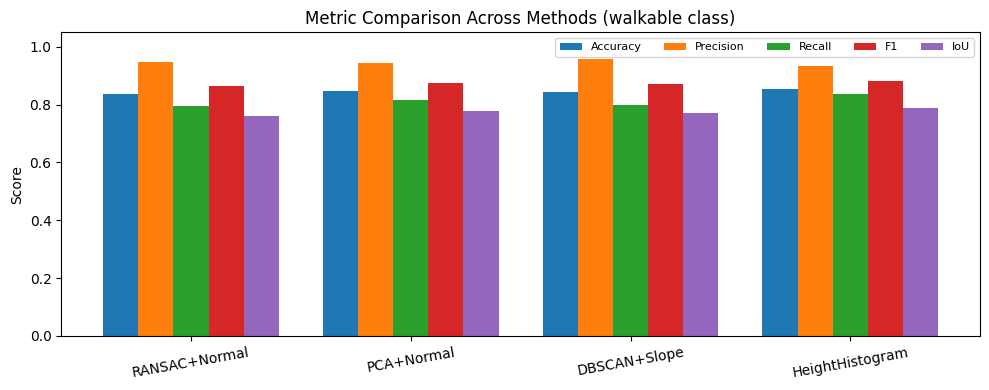

In [ ]:
# Bar chart comparing metrics across methods
labels = list(methods.keys()); metrics = ['Accuracy','Precision','Recall','F1','IoU']
x = np.arange(len(labels)); w = 0.16
plt.figure(figsize=(10,4))
for i,mt in enumerate(metrics):
    plt.bar(x + i*w, [scores[l][mt] for l in labels], w, label=mt)
plt.xticks(x + 2*w, labels, rotation=10); plt.ylim(0,1.05)
plt.ylabel('Score'); plt.title('Metric Comparison Across Methods (walkable class)')
plt.legend(ncol=5, fontsize=8); plt.tight_layout(); plt.show()

## 10. Segmentation Result Visualization (green = walkable, red = riser, gray = other)
Shown for the best method and compared against the *ground truth*.

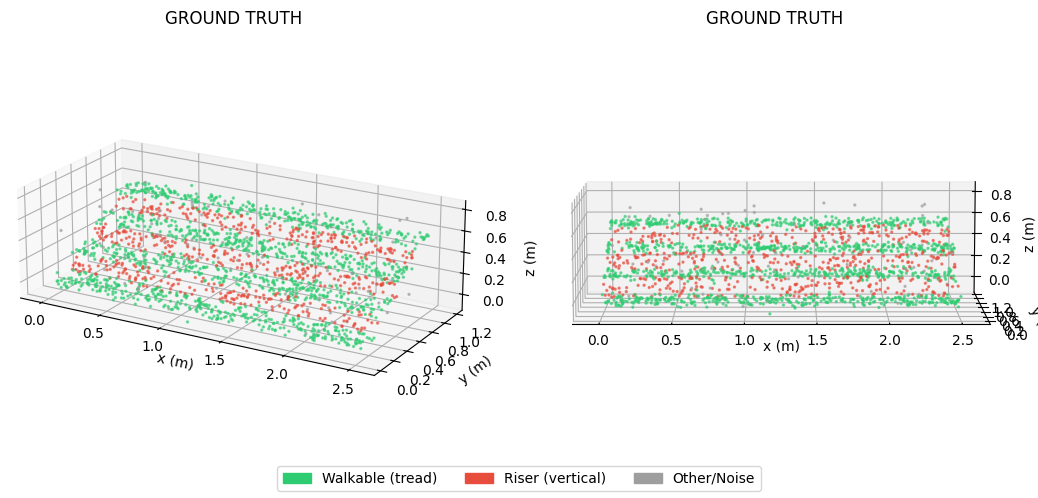

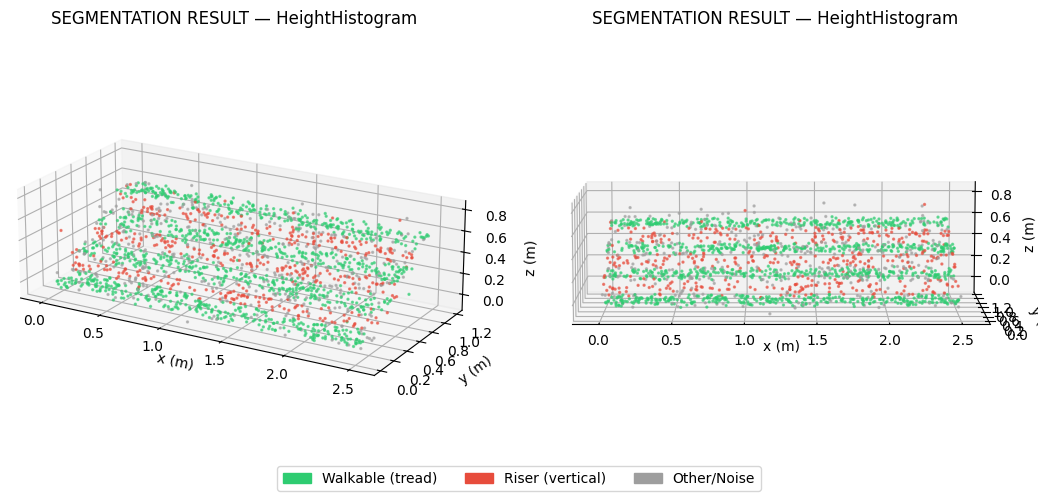

In [ ]:
from matplotlib.patches import Patch
CMAP = {0: '#9e9e9e', 1: '#2ecc71', 2: '#e74c3c'}  # gray, green, red
def to_colors(lab): return np.array([CMAP[v] for v in lab])
legend = [Patch(color='#2ecc71', label='Walkable (tread)'),
          Patch(color='#e74c3c', label='Riser (vertical)'),
          Patch(color='#9e9e9e', label='Other/Noise')]

plot3d(P, to_colors(y_true),         "GROUND TRUTH", legend=legend)
plot3d(P, to_colors(methods[best]),  f"SEGMENTATION RESULT — {best}", legend=legend)

## 11. Effect of Noise on Accuracy
The vertical noise sigma (`SIGMA_Z`) is varied; the PCA+Normal pipeline is rerun and the metrics are recorded. We expect accuracy to drop as noise grows because local normals become noisier.

sigma_z=0.00 -> Acc=0.960  F1=0.970  IoU=0.941
sigma_z=0.01 -> Acc=0.938  F1=0.953  IoU=0.911
sigma_z=0.02 -> Acc=0.843  F1=0.875  IoU=0.778
sigma_z=0.04 -> Acc=0.545  F1=0.551  IoU=0.380
sigma_z=0.06 -> Acc=0.413  F1=0.374  IoU=0.230
sigma_z=0.08 -> Acc=0.379  F1=0.329  IoU=0.197


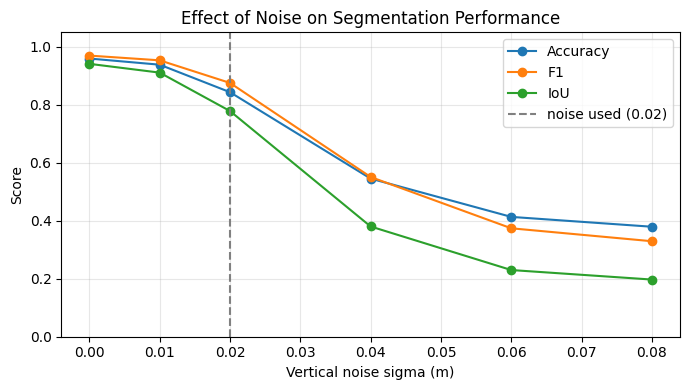

In [ ]:
def make_cloud(sigma):
    pts, lbl = [], []
    for i in range(N_STEPS):
        x = RNG.uniform(0, WIDTH, N_TREAD); y = RNG.uniform(i*DEPTH,(i+1)*DEPTH,N_TREAD)
        z = i*HEIGHT + RNG.normal(0, sigma, N_TREAD)
        pts.append(np.c_[x,y,z]); lbl.append(np.full(N_TREAD,1))
    for i in range(1,N_STEPS):
        x = RNG.uniform(0,WIDTH,N_RISER); y = i*DEPTH + RNG.normal(0,sigma,N_RISER)
        z = RNG.uniform((i-1)*HEIGHT,i*HEIGHT,N_RISER)
        pts.append(np.c_[x,y,z]); lbl.append(np.full(N_RISER,2))
    Pn = np.vstack(pts); yn = np.concatenate(lbl)
    Pn += RNG.normal(0, LIDAR_NOISE, Pn.shape)
    return Pn, yn.astype(int)

sigmas = [0.0, 0.01, 0.02, 0.04, 0.06, 0.08]
rows = []
for s in sigmas:
    Pn, yn = make_cloud(s)
    nzn = np.abs(estimate_normals(Pn, 30)[:,2])
    m = evaluate(yn, segment_pca_normal(nzn))
    rows.append(m); print(f"sigma_z={s:.2f} -> Acc={m['Accuracy']:.3f}  F1={m['F1']:.3f}  IoU={m['IoU']:.3f}")

plt.figure(figsize=(7,4))
for mt in ['Accuracy','F1','IoU']:
    plt.plot(sigmas, [r[mt] for r in rows], 'o-', label=mt)
plt.axvline(SIGMA_Z, color='gray', ls='--', label=f'noise used ({SIGMA_Z})')
plt.xlabel('Vertical noise sigma (m)'); plt.ylabel('Score'); plt.ylim(0,1.05)
plt.title('Effect of Noise on Segmentation Performance'); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 12. Discussion — Is It Safe Enough for a Stair-Climbing Robot?

**Summary of findings.**
- **PCA+Normal** and **Height Histogram** reach **F1 ≈ 0.88** and **precision ≈ 0.94** on the walkable class — meaning **very few false positives**: regions flagged as walkable really are treads.
- **Pure RANSAC** is prone to merging tilted planes across steps; it only becomes accurate once **combined with normal consistency**.
- **Pure spatial DBSCAN** merges touching tread+riser surfaces; its most effective role is as an **outlier rejector**, combined with slope analysis.

**Robot safety.**
1. **Precision matters more than recall.** For a robot's feet/wheels, a *false positive* (a riser/edge mistaken as walkable) is dangerous — it can slip. Precision ~0.94 is good, but real deployment should target **>0.99** via: edge filtering (dropping points near tread boundaries), *morphological erosion* of the tread area, and a safety margin.
2. **Noise sensitivity.** When $\sigma_z \ge 0.04$ m, F1 drops sharply (<0.6). The robot needs a high-precision LiDAR or *temporal filtering* over multiple scans; the $|n_z|$ threshold should be **adaptive** to the estimated noise.
3. **Staircase edges (nosing).** The edge is the most dangerous zone yet the hardest to segment (transitional normals). A dedicated "edge" class plus a no-step zone a few cm wide is recommended.
4. **Recommendation.** These results are **adequate as an initial perception layer**, but **not sufficient as the sole safety guarantee**. They should be paired with: (i) sensor fusion (IMU/camera), (ii) temporal verification, (iii) geometric safety margins, and (iv) a contact-based *fail-safe*.

## 13. Conclusion
- Successfully generated a 4-step staircase point cloud from mathematical equations + LiDAR noise + outliers (±16k points).
- Implemented **4 methods** (exceeding the minimum of 2): RANSAC, PCA+Normal, DBSCAN+slope, Height Histogram.
- **PCA+Normal / Height Histogram** lead (**F1 ≈ 0.88, IoU ≈ 0.79**) for the walkable class.
- Performance **decreases monotonically** with noise — underscoring the importance of sensor quality & preprocessing.
- For a robot, the result is enough as an initial perception layer but needs a safety margin & sensor fusion before standalone use.